In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are
import sys
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.Cartpole_Control_Utils import *
import time

c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Train and evaluate the models

In [2]:
# Create 'Results' folder if it doesn't exist
models_folder = "../results/Trained_Models/"
results_folder = "../results/PerformanceResults/"
videos_folder = "../results/Videos/"

# Make sure the folders exist
for folder in [models_folder, results_folder, videos_folder]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Lists for timing results
results_records = []

#------------------------------------------------------------------------------------------------------------------------------------------------
# Train/evaluate the MPC model
#------------------------------------------------------------------------------------------------------------------------------------------------
start_time = time.time()
mpc_results = evaluate_mpc_controllers(
        horizons=[50,60],
        recompute_intervals=[1,4, 7],
        length_ratios=[1, 2.0, 3.0],
        wind_mus=[0.0, 0.2, 0.4], 
        wind_sigmas=[0.0, 0.2, 0.4],
        results_folder="../results/PerformanceResults/",
        episode_length=500,
        num_episodes=2,
        linear=False,
    )



c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\controller\_mpc.py:885: UserWarning: rterm was not set and defaults to zero. Changes in the control inputs are not penalized. Can lead to oscillatory behavior.
  warnings.warn('rterm was not set and defaults to zero. Changes in the control inputs are not penalized. Can lead to oscillatory behavior.')


SystemError: <built-in function Function_call> returned a result with an error set

## Pole length error


Plot saved to: ../results/PerformanceResults/mpc_performance_length_ratio_h50_wmu0.0_wsig0.0.png


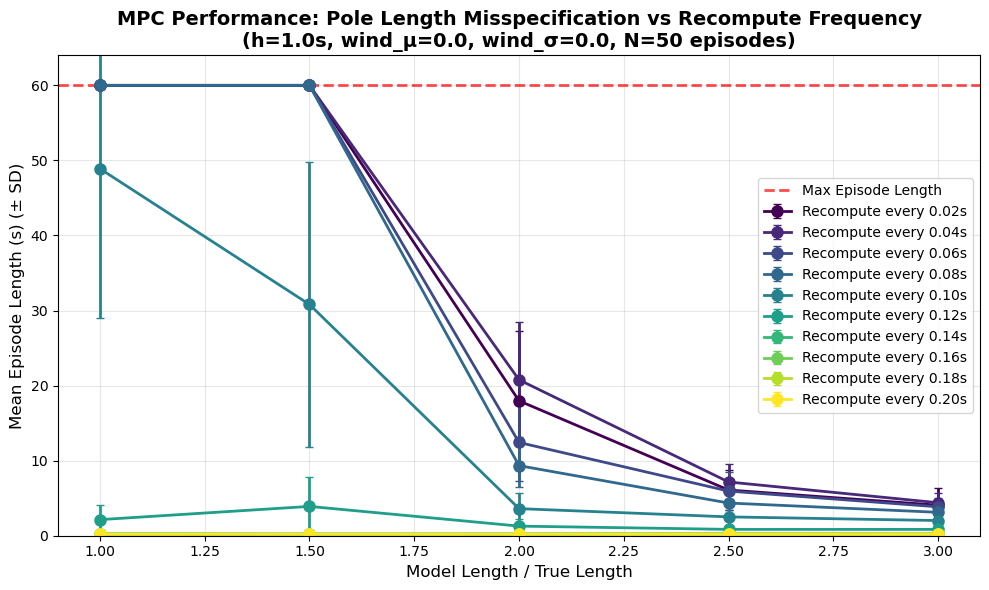

In [3]:
analyze_performance_results_episode_length(
                                episode_length=3000,
                                num_episodes=50,
                                length_ratios=[1.0, 1.5, 2.0, 2.5, 3.0,],
                                horizon=50,
                                wind_mu=0.0)

Found data for horizons: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200] steps = ['0.2s', '0.4s', '0.6s', '0.8s', '1.0s', '1.2s', '1.4s', '1.6s', '1.8s', '2.0s', '2.2s', '2.4s', '2.6s', '2.8s', '3.0s', '3.2s', '3.4s', '3.6s', '3.8s', '4.0s']
Found data for recompute intervals: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] steps = ['0.02s', '0.04s', '0.06s', '0.08s', '0.10s', '0.12s', '0.14s', '0.16s', '0.18s', '0.20s']
Plotting ratios: [1.0, 1.5, 2.0, 2.5, 3.0]

Plot saved to: ../results/PerformanceResults/mpc_4d_performance_heatmaps_wmu0.0_wsig0.0.png


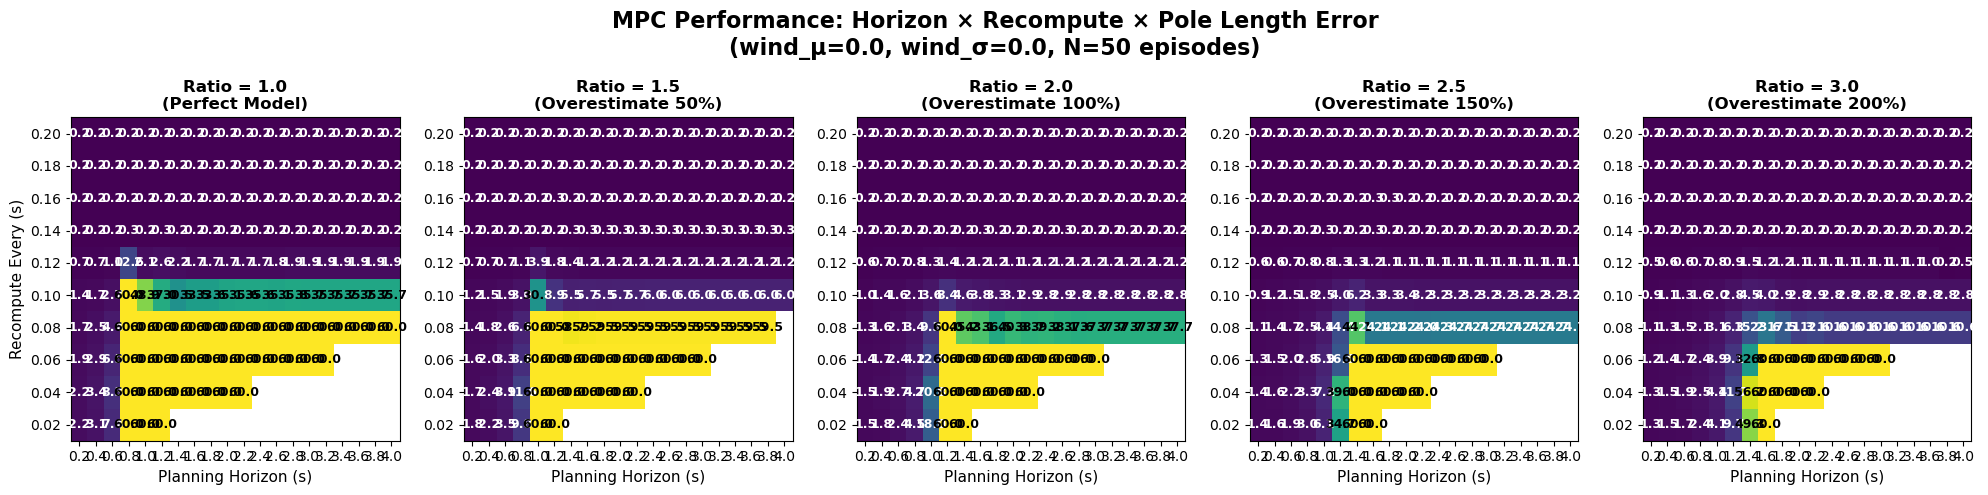

In [4]:
plot_4d_performance_heatmaps(results_folder="../results/PerformanceResults/", 
                                length_ratios=[1.0, 1.5, 2.0, 2.5, 3.0,],
                                wind_mu=0.0,
                                wind_sigma=0.0,
                                num_episodes=50)

## Wind error


Plot saved to: ../results/PerformanceResults/mpc_wind_mu_analysis_h40_r1.0_s0.0.png


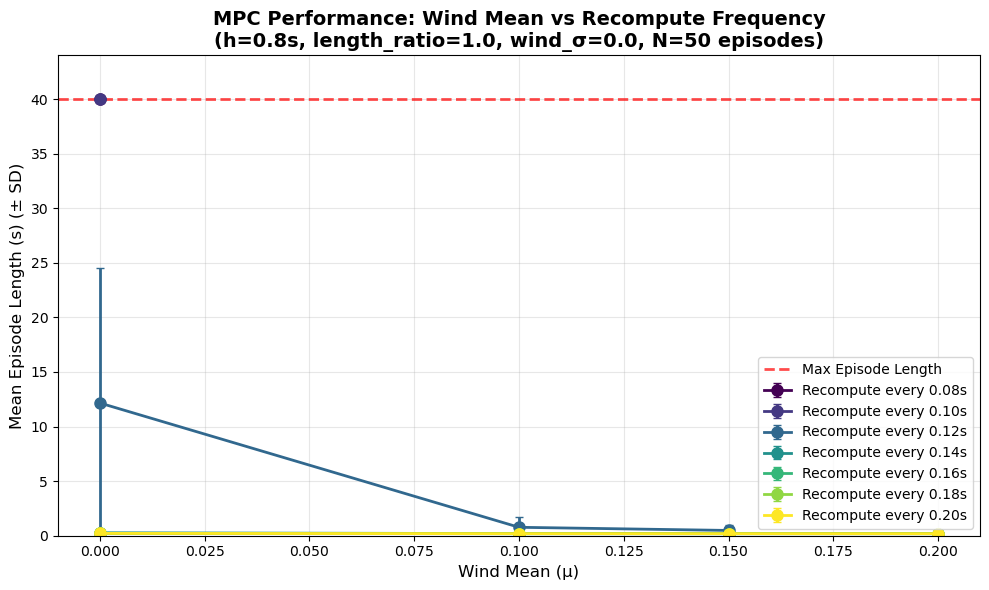

In [42]:
analyze_wind_mu_performance(episode_length=2000,
                               num_episodes=50,
                               wind_mus=[0.0, 0.1, 0.2, 0.3],
                               horizon=40,
                               length_ratio=1.0,
                               wind_sigma=0.0)
                               

Found data for horizons: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200] steps = ['0.2s', '0.4s', '0.6s', '0.8s', '1.0s', '1.2s', '1.4s', '1.6s', '1.8s', '2.0s', '2.2s', '2.4s', '2.6s', '2.8s', '3.0s', '3.2s', '3.4s', '3.6s', '3.8s', '4.0s']
Found data for recompute intervals: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] steps = ['0.02s', '0.04s', '0.06s', '0.08s', '0.10s', '0.12s', '0.14s', '0.16s', '0.18s', '0.20s']
Plotting wind means: [0.0, 0.1, 0.15, 0.2]

Plot saved to: ../results/PerformanceResults/mpc_wind_mu_heatmaps_r1.0_s0.0.png


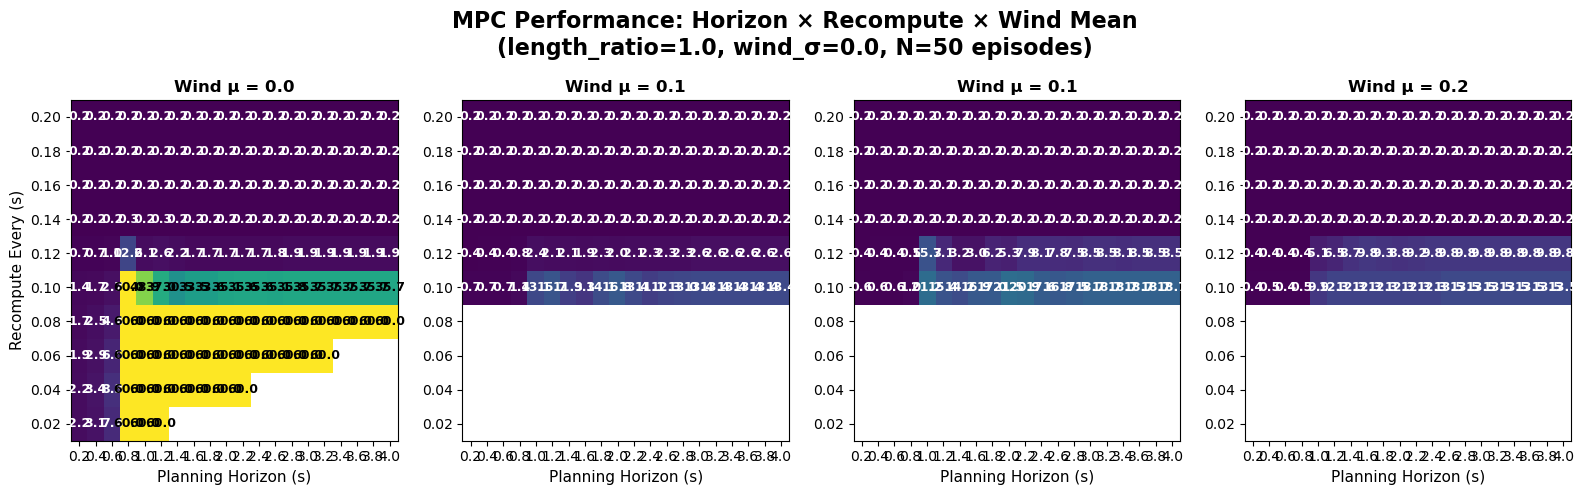

In [6]:
plot_wind_mu_heatmaps(
    results_folder="../results/PerformanceResults/",
    wind_mus=[0.0, 0.1, 0.15, 0.2],
    num_episodes=50,
    length_ratio=1.0,
    wind_sigma=0.0
)

## Plot wind sigma


Plot saved to: ../results/PerformanceResults/mpc_wind_sigma_analysis_h40_r1.0_m0.0.png


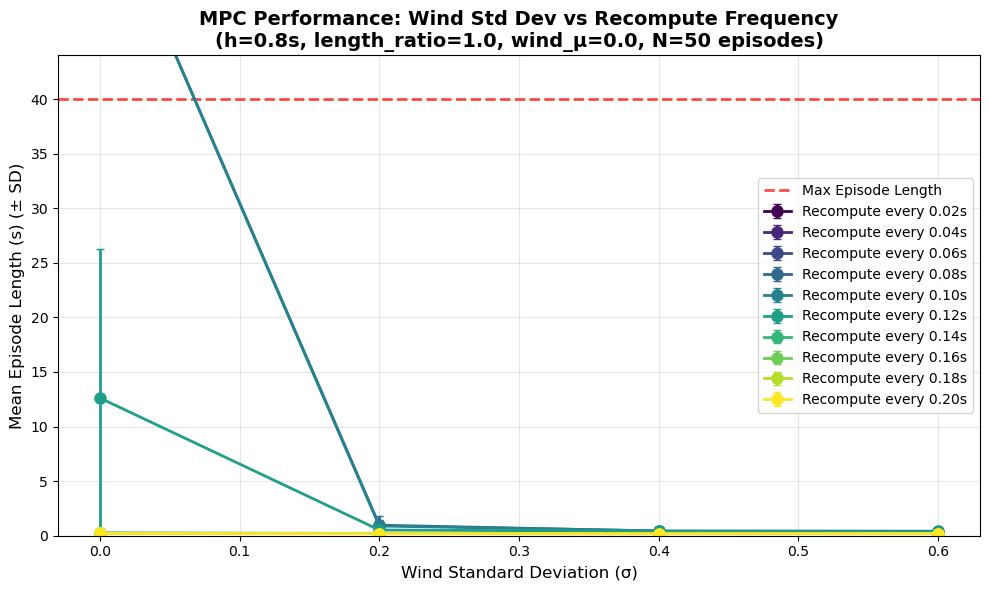

In [7]:
analyze_wind_sigma_performance(episode_length=3000,
                               num_episodes=50,
                               wind_sigmas=[0.0, 0.2, 0.4, 0.6],
                               horizon=40,
                               length_ratio=1.0,
                               wind_mu=0.0)
                               

Found data for horizons: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200] steps = ['0.2s', '0.4s', '0.6s', '0.8s', '1.0s', '1.2s', '1.4s', '1.6s', '1.8s', '2.0s', '2.2s', '2.4s', '2.6s', '2.8s', '3.0s', '3.2s', '3.4s', '3.6s', '3.8s', '4.0s']
Found data for recompute intervals: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] steps = ['0.02s', '0.04s', '0.06s', '0.08s', '0.10s', '0.12s', '0.14s', '0.16s', '0.18s', '0.20s']
Plotting wind std devs: [0.0, 0.2, 0.4, 0.6]

Plot saved to: ../results/PerformanceResults/mpc_wind_sigma_heatmaps_r1.0_m0.0.png


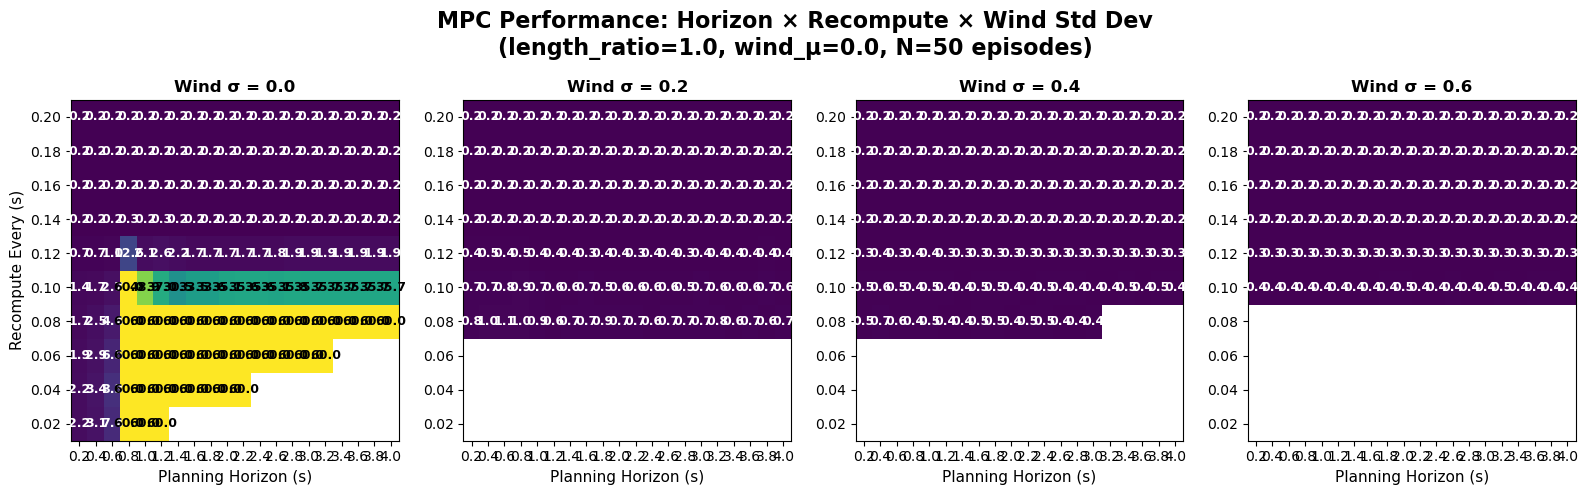

In [8]:
plot_wind_sigma_heatmaps(
    results_folder="../results/PerformanceResults/",
    wind_sigmas=[0.0, 0.2, 0.4, 0.6],
    num_episodes=50,
    length_ratio=1.0,
    wind_mu=0.0
)